# Bocconi Nuclei Challenge — Improved Notebook

This notebook significantly improves over the starter baseline.

**Task 1 — Detection**: Faster R-CNN with **ResNet-50 FPN v2**, full training data, augmentation, LR scheduling, and score-threshold tuning.  
**Task 2 — Segmentation**: Proper **U-Net with BatchNorm**, mixed Dice+BCE loss, augmentation, and threshold tuning.

Course: **Computer Vision and Image Processing**  
Instructor: **Prof. Chiara Plizzari**  
Teaching assistant: **Francesca Pia Panaccione**

## 1. Challenge format

Important distinction:

- the **training detection labels** contain **one row per nucleus**
- the **Kaggle detection submission** contains **one row per image** with a serialized `boxes` string

Detection submission format:
- columns: `image_id, boxes`
- example: `12 20 40 55; 80 90 100 115`

Segmentation submission format:
- columns: `image_id, rle_mask`

In [1]:
!pip -q install opencv-python-headless

import random
import zipfile
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader, Dataset

# ── Detection imports ──────────────────────────────────────────────────────────
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn_v2,
    FasterRCNN_ResNet50_FPN_V2_Weights,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 256
NUM_WORKERS = 2

print('Device:', DEVICE)
print('PyTorch:', torch.__version__)

Device: cuda
PyTorch: 2.10.0+cu128


## 2. Load the dataset from Google Drive

In [2]:
from google.colab import drive

drive.mount('/content/drive')

BASE_DIR = Path('/content/drive/MyDrive')
ZIP_PATH = BASE_DIR / 'monuseg_challenge_v2_dataset.zip'
EXTRACT_DIR = Path('/content/monuseg_challenge_v2')
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

if not ZIP_PATH.exists():
    raise FileNotFoundError(f'Zip not found: {ZIP_PATH}')
if not any(EXTRACT_DIR.iterdir()):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_DIR)

DATA_ROOT = EXTRACT_DIR / 'kaggle_upload_v2' / 'dataset'
if not DATA_ROOT.exists():
    candidates = [EXTRACT_DIR] + [p for p in EXTRACT_DIR.rglob('dataset') if p.is_dir()]
    found = None
    for c in candidates:
        if (c / 'train' / 'images').exists() and (c / 'test' / 'images').exists():
            found = c
            break
    if found is None:
        raise FileNotFoundError('Could not locate dataset/train/images and dataset/test/images')
    DATA_ROOT = found

TRAIN_IMG_DIR = DATA_ROOT / 'train' / 'images'
TEST_IMG_DIR  = DATA_ROOT / 'test'  / 'images'
df_det  = pd.read_csv(DATA_ROOT / 'train' / 'train_labels_detection.csv')
df_seg  = pd.read_csv(DATA_ROOT / 'train' / 'train_labels_segmentation.csv')
df_meta = pd.read_csv(DATA_ROOT / 'train' / 'train_metadata.csv')
TRAIN_IDS = sorted(df_seg['image_id'].tolist())
TEST_IDS  = sorted(int(p.stem) for p in TEST_IMG_DIR.glob('*.png'))

print('DATA_ROOT     =', DATA_ROOT)
print('Train images  =', len(TRAIN_IDS))
print('Test images   =', len(TEST_IDS))
print('Detection rows=', len(df_det))

Mounted at /content/drive
DATA_ROOT     = /content/monuseg_challenge_v2/dataset
Train images  = 900
Test images   = 280
Detection rows= 38414


## 3. Utility functions (unchanged from starter)

In [3]:
# Build lookup tables
det_lu   = {int(k): g.reset_index(drop=True) for k, g in df_det.groupby('image_id')}
seg_lu   = df_seg.set_index('image_id')
meta_lu  = df_meta.set_index('image_id')


def load_img(image_id, split='train'):
    folder = TRAIN_IMG_DIR if split == 'train' else TEST_IMG_DIR
    return np.array(
        Image.open(folder / f'{image_id:04d}.png').convert('RGB'), dtype=np.uint8
    )


def rle_to_mask(rle, h=IMG_SIZE, w=IMG_SIZE):
    mask = np.zeros(h * w, dtype=np.uint8)
    if pd.isna(rle) or str(rle).strip() == '':
        return mask.reshape(h, w)
    parts = list(map(int, str(rle).split()))
    for s, l in zip(parts[0::2], parts[1::2]):
        mask[s:s + l] = 1
    return mask.reshape(h, w)


def mask_to_rle(mask):
    pixels = mask.astype(np.uint8).reshape(-1)
    pixels = np.concatenate([[0], pixels, [0]])
    runs   = np.where(pixels[1:] != pixels[:-1])[0]
    starts, ends = runs[::2], runs[1::2]
    out = []
    for s, l in zip(starts, ends - starts):
        out.extend([str(int(s)), str(int(l))])
    return ' '.join(out)


def serialize_boxes(boxes):
    if not boxes:
        return ''
    return '; '.join(f'{int(x1)} {int(y1)} {int(x2)} {int(y2)}' for x1, y1, x2, y2 in boxes)


def get_boxes(image_id):
    rows = det_lu.get(int(image_id), pd.DataFrame(columns=['x1', 'y1', 'x2', 'y2']))
    return rows[['x1', 'y1', 'x2', 'y2']].astype(int).values.tolist()


def get_train_sample(image_id):
    img   = load_img(image_id, 'train')
    mask  = rle_to_mask(seg_lu.loc[image_id, 'rle_mask'])
    boxes = get_boxes(image_id)
    meta  = meta_lu.loc[image_id]
    return img, mask, boxes, meta

## 4. Quick preview

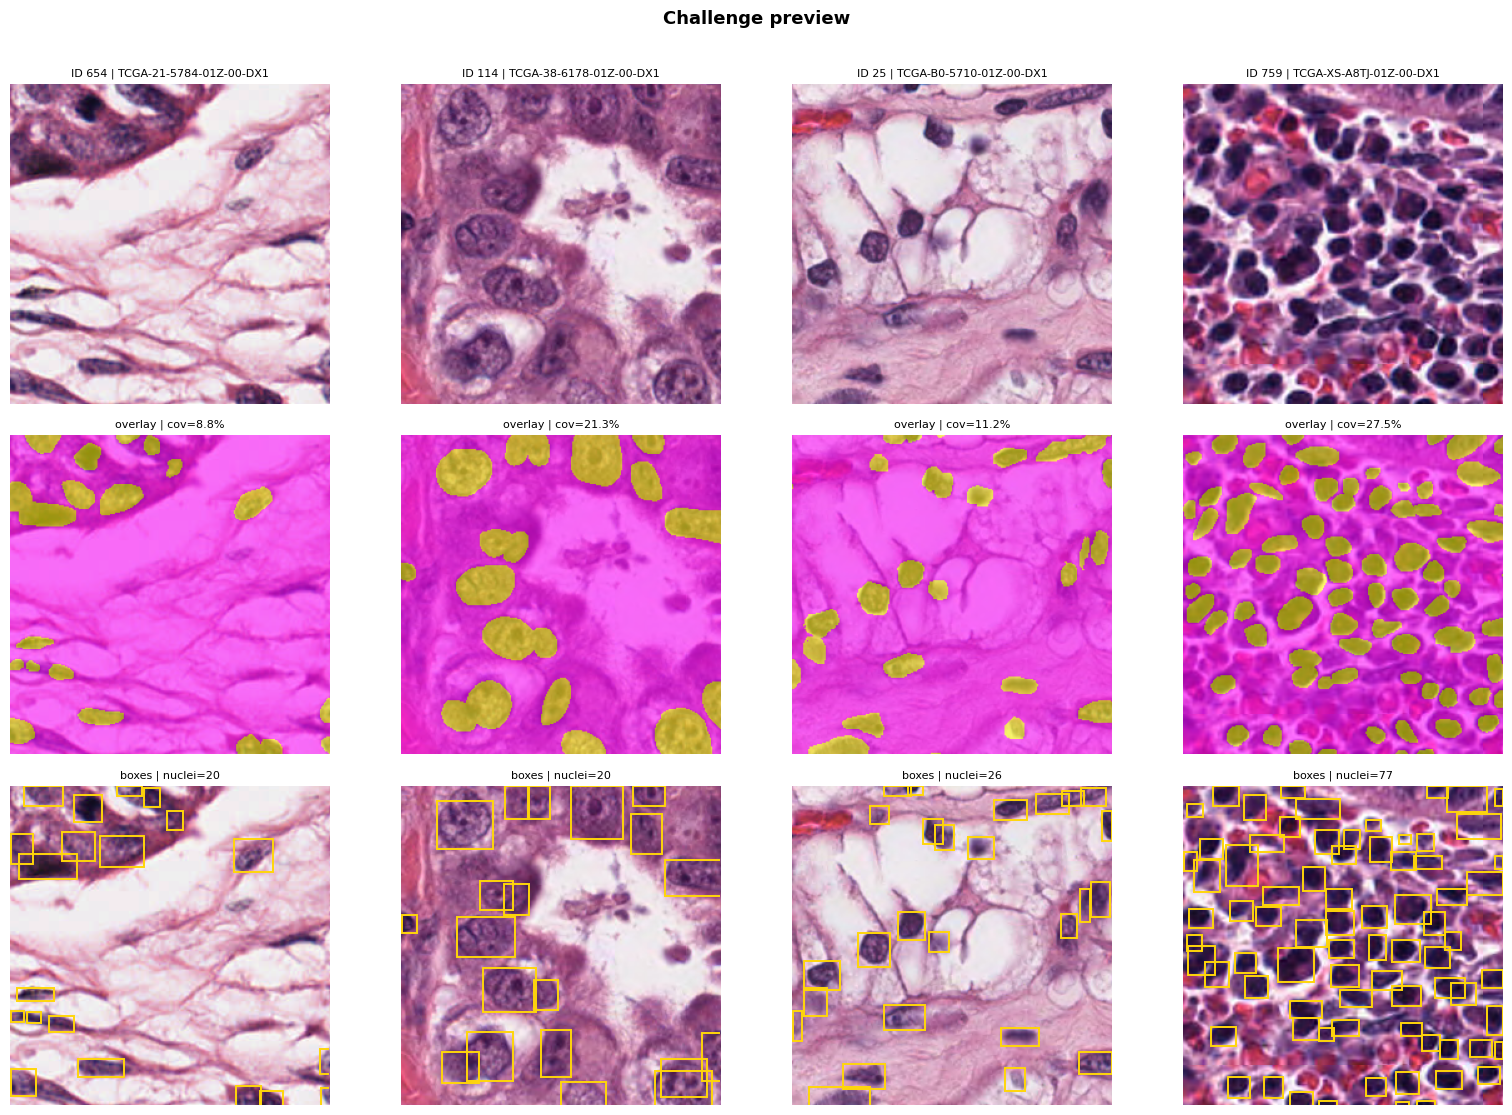

In [4]:
sample_ids = random.sample(TRAIN_IDS, 4)
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
fig.suptitle('Challenge preview', fontsize=13, fontweight='bold', y=1.01)

for col, image_id in enumerate(sample_ids):
    img, mask, boxes, meta = get_train_sample(image_id)

    axes[0, col].imshow(img)
    axes[0, col].set_title(f'ID {image_id} | {meta.source_slide}', fontsize=8)
    axes[0, col].axis('off')

    axes[1, col].imshow(img)
    axes[1, col].imshow(mask, cmap='spring', alpha=0.55)
    axes[1, col].set_title(f'overlay | cov={100 * mask.mean():.1f}%', fontsize=8)
    axes[1, col].axis('off')

    axes[2, col].imshow(img)
    for x1, y1, x2, y2 in boxes:
        axes[2, col].add_patch(
            mpatches.Rectangle((x1, y1), x2 - x1 + 1, y2 - y1 + 1,
                                fill=False, edgecolor='#ffd60a', linewidth=1.4))
    axes[2, col].set_title(f'boxes | nuclei={len(boxes)}', fontsize=8)
    axes[2, col].axis('off')

plt.tight_layout()
plt.show()

## 5. Train / validation split (slide-level)

We split by **source slide** to avoid leakage across patches from the same slide.
We now use **100 % of the available training slides** (the starter used only 35 %).

In [5]:
slide_names = sorted(df_meta['source_slide'].unique().tolist())
random.shuffle(slide_names)

n_train_slides   = max(1, int(len(slide_names) * 0.80))
train_slide_names = set(slide_names[:n_train_slides])
val_slide_names   = set(slide_names[n_train_slides:])

train_ids = [i for i in TRAIN_IDS if meta_lu.loc[i, 'source_slide'] in train_slide_names]
val_ids   = [i for i in TRAIN_IDS if meta_lu.loc[i, 'source_slide'] in val_slide_names]

print(f'Train images : {len(train_ids)}  (using ALL — no BASELINE_FRAC cut)')
print(f'Val images   : {len(val_ids)}')

Train images : 706  (using ALL — no BASELINE_FRAC cut)
Val images   : 194


## 6. Local validation metrics

In [6]:
def box_iou(b1, b2):
    ix1, iy1 = max(b1[0], b2[0]), max(b1[1], b2[1])
    ix2, iy2 = min(b1[2], b2[2]), min(b1[3], b2[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    a1 = max(0, b1[2] - b1[0]) * max(0, b1[3] - b1[1])
    a2 = max(0, b2[2] - b2[0]) * max(0, b2[3] - b2[1])
    return inter / (a1 + a2 - inter + 1e-8)


def detection_f1(preds, gts, iou_thr=0.5):
    tp = fp = fn = 0
    for image_id, gt_boxes in gts.items():
        pred_boxes = preds.get(image_id, [])
        matched = [False] * len(gt_boxes)
        for pb in pred_boxes:
            best_iou, best_j = 0.0, -1
            for j, gb in enumerate(gt_boxes):
                if matched[j]:
                    continue
                iou = box_iou(pb, gb)
                if iou > best_iou:
                    best_iou, best_j = iou, j
            if best_iou >= iou_thr:
                tp += 1
                matched[best_j] = True
            else:
                fp += 1
        fn += matched.count(False)
    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    return float(f1), float(precision), float(recall)


def dice_score(pred, gt, thr=0.35):
    p = (pred > thr).astype(np.uint8)
    g = (gt > 0.5).astype(np.uint8)
    inter = (p & g).sum()
    return float(2 * inter / (p.sum() + g.sum() + 1e-8))

## 7. Detection — Faster R-CNN with ResNet-50 FPN v2

### Improvements over the starter:
| What | Starter | This notebook |
|---|---|---|
| Backbone | MobileNet V3 | **ResNet-50 FPN v2** |
| Training data | 35 % | **100 %** |
| Augmentation | None | **H-flip, V-flip, Color jitter** |
| Epochs | 3 | **12** |
| LR schedule | None | **Cosine annealing** |
| Score threshold | fixed 0.50 | **Tuned on validation** |

In [7]:
# ──────────────────────────────────────────────────────────────────────────────
# Bounding-box-aware augmentation
# We apply random horizontal flip, vertical flip, and colour jitter.
# Colour jitter touches only pixel values so it does not require box updates.
# Flips do require updating box coordinates.
# ──────────────────────────────────────────────────────────────────────────────
import torchvision.transforms as T

_color_jitter = T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1)


def augment_det(image_tensor, boxes_tensor, p=0.5):
    """
    Apply random flips and colour jitter to a (C, H, W) float image tensor
    and its corresponding bounding boxes (N, 4) in [x1, y1, x2, y2] format.

    Returns augmented (image_tensor, boxes_tensor).
    """
    W = image_tensor.shape[2]
    H = image_tensor.shape[1]
    n = boxes_tensor.shape[0]

    # ── Horizontal flip ──────────────────────────────────────────────────────
    if random.random() < p:
        image_tensor = TF.hflip(image_tensor)
        if n > 0:
            x1 = boxes_tensor[:, 0].clone()
            x2 = boxes_tensor[:, 2].clone()
            boxes_tensor[:, 0] = W - 1 - x2
            boxes_tensor[:, 2] = W - 1 - x1

    # ── Vertical flip ────────────────────────────────────────────────────────
    if random.random() < p:
        image_tensor = TF.vflip(image_tensor)
        if n > 0:
            y1 = boxes_tensor[:, 1].clone()
            y2 = boxes_tensor[:, 3].clone()
            boxes_tensor[:, 1] = H - 1 - y2
            boxes_tensor[:, 3] = H - 1 - y1

    # ── Colour jitter (image only) ────────────────────────────────────────────
    # Convert to PIL for ColorJitter, then back to tensor
    pil = TF.to_pil_image(image_tensor)
    pil = _color_jitter(pil)
    image_tensor = TF.to_tensor(pil)

    # ── Safety: clip and remove degenerate boxes ──────────────────────────────
    if n > 0:
        boxes_tensor[:, 0::2] = boxes_tensor[:, 0::2].clamp(0, W - 1)
        boxes_tensor[:, 1::2] = boxes_tensor[:, 1::2].clamp(0, H - 1)
        valid = (boxes_tensor[:, 2] > boxes_tensor[:, 0] + 1) & (
                 boxes_tensor[:, 3] > boxes_tensor[:, 1] + 1)
        boxes_tensor = boxes_tensor[valid]

    return image_tensor, boxes_tensor

In [8]:
class DetectionDataset(Dataset):
    """Detection dataset with optional augmentation."""

    def __init__(self, ids, augment=False):
        self.ids     = ids
        self.augment = augment

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        image_id = self.ids[idx]
        img      = load_img(image_id, 'train')
        boxes    = get_boxes(image_id)

        image = torch.from_numpy(img).float().permute(2, 0, 1) / 255.0

        if len(boxes) == 0:
            boxes_tensor = torch.zeros((0, 4), dtype=torch.float32)
            labels_tensor = torch.zeros((0,), dtype=torch.int64)
            area_tensor   = torch.zeros((0,), dtype=torch.float32)
        else:
            boxes_tensor  = torch.tensor(boxes, dtype=torch.float32)
            labels_tensor = torch.ones((len(boxes),), dtype=torch.int64)
            area_tensor   = ((boxes_tensor[:, 2] - boxes_tensor[:, 0]) *
                             (boxes_tensor[:, 3] - boxes_tensor[:, 1]))

        # ── Augmentation ──────────────────────────────────────────────────────
        if self.augment:
            image, boxes_tensor = augment_det(image, boxes_tensor)
            labels_tensor = torch.ones((boxes_tensor.shape[0],), dtype=torch.int64)
            area_tensor   = ((boxes_tensor[:, 2] - boxes_tensor[:, 0]) *
                             (boxes_tensor[:, 3] - boxes_tensor[:, 1]))

        target = {
            'boxes':    boxes_tensor,
            'labels':   labels_tensor,
            'image_id': torch.tensor([image_id]),
            'area':     area_tensor,
            'iscrowd':  torch.zeros((boxes_tensor.shape[0],), dtype=torch.int64),
        }
        return image, target


def det_collate_fn(batch):
    return tuple(zip(*batch))

In [9]:
# ── Model: Faster R-CNN with ResNet-50 FPN v2 ────────────────────────────────
# ResNet-50 FPN v2 is significantly stronger than the MobileNet backbone
# used in the starter while still being reasonably fast on a Colab T4.
weights   = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
det_model = fasterrcnn_resnet50_fpn_v2(weights=weights)

# Replace the head: 2 classes (background + nucleus)
in_features = det_model.roi_heads.box_predictor.cls_score.in_features
det_model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes=2)
det_model = det_model.to(DEVICE)

# ── Data loaders ─────────────────────────────────────────────────────────────
DET_BATCH   = 4
DET_EPOCHS  = 12

train_det_dl = DataLoader(
    DetectionDataset(train_ids, augment=True),
    batch_size=DET_BATCH,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=det_collate_fn,
)

# ── Optimiser & LR scheduler ──────────────────────────────────────────────────
# We use a two-phase strategy:
#  • backbone parameters at a lower LR (fine-tuning from COCO weights)
#  • detection head at a higher LR (trained from scratch)
backbone_params = [p for n, p in det_model.named_parameters()
                   if p.requires_grad and 'backbone' in n]
head_params     = [p for n, p in det_model.named_parameters()
                   if p.requires_grad and 'backbone' not in n]

optimizer_det = optim.AdamW([
    {'params': backbone_params, 'lr': 2e-5},
    {'params': head_params,     'lr': 1e-4},
], weight_decay=1e-4)

scheduler_det = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_det, T_max=DET_EPOCHS, eta_min=1e-6
)

# ── Training loop ─────────────────────────────────────────────────────────────
for ep in range(1, DET_EPOCHS + 1):
    det_model.train()
    running_loss = 0.0
    for images, targets in tqdm(train_det_dl, desc=f'det train {ep}/{DET_EPOCHS}'):
        images  = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        loss_dict    = det_model(images, targets)
        loss         = sum(loss_dict.values())
        optimizer_det.zero_grad()
        loss.backward()
        # Gradient clipping improves training stability
        torch.nn.utils.clip_grad_norm_(det_model.parameters(), max_norm=5.0)
        optimizer_det.step()
        running_loss += float(loss.item())

    scheduler_det.step()
    lr_now = scheduler_det.get_last_lr()[0]
    print(f'Epoch {ep:02d} | det_loss = {running_loss / max(len(train_det_dl), 1):.4f}'
          f' | lr = {lr_now:.2e}')

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:01<00:00, 92.5MB/s]


det train 1/12:   0%|          | 0/177 [00:00<?, ?it/s]

Epoch 01 | det_loss = 1.0565 | lr = 1.97e-05


det train 2/12:   0%|          | 0/177 [00:00<?, ?it/s]

...

Epoch 10 | det_loss = 0.6699 | lr = 2.27e-06


det train 11/12:   0%|          | 0/177 [00:00<?, ?it/s]

Epoch 11 | det_loss = 0.6656 | lr = 1.32e-06


det train 12/12:   0%|          | 0/177 [00:00<?, ?it/s]

Epoch 12 | det_loss = 0.6595 | lr = 1.00e-06


In [10]:
def predict_boxes_frcnn(img_np, model, score_thr=0.50):
    """Run inference on one image and return kept boxes as [[x1,y1,x2,y2], ...]."""
    model.eval()
    x = torch.from_numpy(img_np).float().permute(2, 0, 1).unsqueeze(0) / 255.0
    with torch.no_grad():
        pred = model([x[0].to(DEVICE)])[0]
    boxes  = pred['boxes'].detach().cpu().numpy()
    scores = pred['scores'].detach().cpu().numpy()

    keep   = scores >= score_thr
    boxes  = boxes[keep]

    out = []
    for x1, y1, x2, y2 in boxes:
        x1 = int(np.clip(round(x1), 0, IMG_SIZE - 1))
        y1 = int(np.clip(round(y1), 0, IMG_SIZE - 1))
        x2 = int(np.clip(round(x2), 0, IMG_SIZE - 1))
        y2 = int(np.clip(round(y2), 0, IMG_SIZE - 1))
        if x2 > x1 and y2 > y1:
            out.append([x1, y1, x2, y2])
    return out


# ── Score-threshold search on validation set ─────────────────────────────────
# We first collect all raw predictions (with low threshold 0.05) so we do not
# need to re-run the model for each candidate threshold.
val_det_gts       = {i: get_boxes(i) for i in val_ids}
val_raw_preds     = {}  # image_id -> (boxes_array, scores_array)

det_model.eval()
for image_id in tqdm(val_ids, desc='det val inference'):
    img  = load_img(image_id, 'train')
    x    = torch.from_numpy(img).float().permute(2, 0, 1).unsqueeze(0) / 255.0
    with torch.no_grad():
        pred = det_model([x[0].to(DEVICE)])[0]
    val_raw_preds[image_id] = (
        pred['boxes'].cpu().numpy(),
        pred['scores'].cpu().numpy(),
    )

# ── Sweep thresholds 0.20 .. 0.75 ────────────────────────────────────────────
best_f1, best_thr = 0.0, 0.50
for thr in np.arange(0.20, 0.76, 0.05):
    preds = {}
    for image_id, (boxes, scores) in val_raw_preds.items():
        keep   = scores >= thr
        b      = boxes[keep]
        out    = []
        for x1, y1, x2, y2 in b:
            x1 = int(np.clip(round(x1), 0, IMG_SIZE - 1))
            y1 = int(np.clip(round(y1), 0, IMG_SIZE - 1))
            x2 = int(np.clip(round(x2), 0, IMG_SIZE - 1))
            y2 = int(np.clip(round(y2), 0, IMG_SIZE - 1))
            if x2 > x1 and y2 > y1:
                out.append([x1, y1, x2, y2])
        preds[image_id] = out
    f1, prec, rec = detection_f1(preds, val_det_gts)
    print(f'  thr={thr:.2f} | F1={f1:.4f} | P={prec:.4f} | R={rec:.4f}')
    if f1 > best_f1:
        best_f1, best_thr = f1, thr

DET_SCORE_THR = best_thr
print(f'\nBest score threshold: {DET_SCORE_THR:.2f}  →  val F1 = {best_f1:.4f}')

det val inference:   0%|          | 0/194 [00:00<?, ?it/s]

  thr=0.20 | F1=0.7739 | P=0.7060 | R=0.8562
  thr=0.25 | F1=0.7884 | P=0.7345 | R=0.8508
  thr=0.30 | F1=0.7987 | P=0.7575 | R=0.8447
  thr=0.35 | F1=0.8073 | P=0.7766 | R=0.8405
  thr=0.40 | F1=0.8140 | P=0.7929 | R=0.8362
  thr=0.45 | F1=0.8196 | P=0.8085 | R=0.8309
  thr=0.50 | F1=0.8247 | P=0.8248 | R=0.8247
  thr=0.55 | F1=0.8282 | P=0.8389 | R=0.8178
  thr=0.60 | F1=0.8296 | P=0.8503 | R=0.8098
  thr=0.65 | F1=0.8291 | P=0.8623 | R=0.7984
  thr=0.70 | F1=0.8282 | P=0.8764 | R=0.7851
  thr=0.75 | F1=0.8255 | P=0.8895 | R=0.7702

Best score threshold: 0.60  →  val F1 = 0.8296


In [11]:
# Save the trained detection model to Drive so you can reload it later
DET_CKPT = BASE_DIR / 'det_model_resnet50.pth'
torch.save(det_model.state_dict(), DET_CKPT)
print('Detection model saved to:', DET_CKPT)

Detection model saved to: /content/drive/MyDrive/det_model_resnet50.pth


## 8. Detection submission for Kaggle

In [12]:
det_rows = []
for image_id in tqdm(TEST_IDS, desc='det test'):
    img   = load_img(image_id, 'test')
    boxes = predict_boxes_frcnn(img, det_model, score_thr=DET_SCORE_THR)
    det_rows.append({'image_id': image_id, 'boxes': serialize_boxes(boxes)})

pd.DataFrame(det_rows, columns=['image_id', 'boxes']).to_csv(
    'submission_detection.csv', index=False
)
print('Saved submission_detection.csv')

det test:   0%|          | 0/280 [00:00<?, ?it/s]

Saved submission_detection.csv


## 9. Segmentation — U-Net with BatchNorm

### Improvements over the starter:
| What | Starter | This notebook |
|---|---|---|
| Architecture | TinyUNet (no BN) | **U-Net with BatchNorm + Dropout** |
| Loss | BCE only | **Dice + BCE (mixed)** |
| Training data | 35 % | **100 %** |
| Augmentation | None | **H-flip, V-flip, Color jitter** |
| Epochs | 3 | **20** |
| LR schedule | None | **Cosine annealing** |
| Threshold | fixed 0.35 | **Tuned on validation** |

In [13]:
def augment_seg(image_tensor, mask_tensor, p=0.5):
    """
    Apply random flips and colour jitter to a segmentation sample.

    Parameters
    ----------
    image_tensor : torch.Tensor  (C, H, W)
    mask_tensor  : torch.Tensor  (1, H, W)

    Returns
    -------
    image_tensor, mask_tensor  (same types, same shapes, augmented)
    """
    # Horizontal flip
    if random.random() < p:
        image_tensor = TF.hflip(image_tensor)
        mask_tensor  = TF.hflip(mask_tensor)

    # Vertical flip
    if random.random() < p:
        image_tensor = TF.vflip(image_tensor)
        mask_tensor  = TF.vflip(mask_tensor)

    # Random 90-degree rotation (image and mask together)
    if random.random() < p:
        k = random.choice([1, 2, 3])  # 90, 180, or 270 degrees
        image_tensor = torch.rot90(image_tensor, k, dims=[1, 2])
        mask_tensor  = torch.rot90(mask_tensor,  k, dims=[1, 2])

    # Colour jitter (image only, mask is binary so untouched)
    pil          = TF.to_pil_image(image_tensor)
    pil          = _color_jitter(pil)
    image_tensor = TF.to_tensor(pil)

    return image_tensor, mask_tensor

In [14]:
class ConvBnRelu(nn.Module):
    """3×3 Conv → BatchNorm → ReLU block, the basic building brick of U-Net."""
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    """
    Standard U-Net with BatchNorm and optional dropout in the bottleneck.

    Architecture:
      encoder: 3 down-sampling levels (maxpool + ConvBnRelu)
      bottleneck: ConvBnRelu with dropout
      decoder: 3 up-sampling levels (transposed conv + skip + ConvBnRelu)
      head: 1×1 Conv → single-channel logit map

    Input:  (B, 3,  256, 256)
    Output: (B, 1,  256, 256)  — raw logits (apply sigmoid for probabilities)
    """
    def __init__(self, base=32, dropout=0.3):
        super().__init__()
        b = base

        # Encoder
        self.enc1 = ConvBnRelu(3,      b)
        self.enc2 = ConvBnRelu(b,      b * 2)
        self.enc3 = ConvBnRelu(b * 2,  b * 4)

        # Bottleneck (widest, most abstract features)
        self.bot  = ConvBnRelu(b * 4,  b * 8, dropout=dropout)

        # Decoder (each step: upsample → concatenate skip → ConvBnRelu)
        self.up3  = nn.ConvTranspose2d(b * 8, b * 4, kernel_size=2, stride=2)
        self.dec3 = ConvBnRelu(b * 8,  b * 4)

        self.up2  = nn.ConvTranspose2d(b * 4, b * 2, kernel_size=2, stride=2)
        self.dec2 = ConvBnRelu(b * 4,  b * 2)

        self.up1  = nn.ConvTranspose2d(b * 2, b,     kernel_size=2, stride=2)
        self.dec1 = ConvBnRelu(b * 2,  b)

        # Output head
        self.head = nn.Conv2d(b, 1, kernel_size=1)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        e1  = self.enc1(x)
        e2  = self.enc2(self.pool(e1))
        e3  = self.enc3(self.pool(e2))
        b   = self.bot(self.pool(e3))
        d3  = self.dec3(torch.cat([self.up3(b),  e3], dim=1))
        d2  = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1  = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.head(d1)

In [15]:
def dice_loss(logits, targets, smooth=1.0):
    """
    Soft Dice loss computed on sigmoid probabilities.

    Dice loss directly optimises overlap between predicted and ground-truth
    foreground pixels, and is much less sensitive to class imbalance than
    plain BCE.  We combine it with BCE for training stability.
    """
    probs   = torch.sigmoid(logits)
    probs_f = probs.view(-1)
    tgt_f   = targets.view(-1)
    inter   = (probs_f * tgt_f).sum()
    return 1.0 - (2.0 * inter + smooth) / (probs_f.sum() + tgt_f.sum() + smooth)


class SegDataset(Dataset):
    """Segmentation dataset with optional augmentation."""
    def __init__(self, ids, augment=False):
        self.ids     = ids
        self.augment = augment

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        image_id         = self.ids[idx]
        img, mask, _, _  = get_train_sample(image_id)
        x = torch.from_numpy(img).float().permute(2, 0, 1) / 255.0
        y = torch.from_numpy(mask).float().unsqueeze(0)

        if self.augment:
            x, y = augment_seg(x, y)

        return x, y

In [16]:
# ── Class-imbalance weight ────────────────────────────────────────────────────
train_coverages   = [rle_to_mask(seg_lu.loc[i, 'rle_mask']).mean() for i in train_ids]
mean_fg           = float(np.mean(train_coverages))
pos_weight_value  = min(8.0, max(1.0, (1.0 - mean_fg) / max(mean_fg, 1e-6)))
print(f'mean foreground coverage : {mean_fg:.4f}')
print(f'pos_weight               : {pos_weight_value:.4f}')

# ── Model, loss, optimiser ────────────────────────────────────────────────────
seg_model   = UNet(base=32, dropout=0.3).to(DEVICE)
bce_loss_fn = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_value], device=DEVICE)
)

def combined_loss(logits, targets, bce_w=0.6, dice_w=0.4):
    """Weighted combination of BCE and Dice losses."""
    return bce_w * bce_loss_fn(logits, targets) + dice_w * dice_loss(logits, targets)

optimizer_seg = optim.AdamW(seg_model.parameters(), lr=1e-3, weight_decay=1e-4)

SEG_EPOCHS = 20
scheduler_seg = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_seg, T_max=SEG_EPOCHS, eta_min=1e-5
)

train_seg_dl = DataLoader(
    SegDataset(train_ids, augment=True),
    batch_size=16, shuffle=True, num_workers=NUM_WORKERS
)
val_seg_dl = DataLoader(
    SegDataset(val_ids, augment=False),
    batch_size=16, shuffle=False, num_workers=NUM_WORKERS
)

SEG_THRESHOLD = 0.40  # initial default; will be tuned below

best_val_dice = 0.0

for ep in range(1, SEG_EPOCHS + 1):
    # ── Train ────────────────────────────────────────────────────────────────
    seg_model.train()
    running_loss = 0.0
    for imgs, masks in tqdm(train_seg_dl, desc=f'seg train {ep}/{SEG_EPOCHS}'):
        imgs  = imgs.to(DEVICE)
        masks = masks.to(DEVICE)
        loss  = combined_loss(seg_model(imgs), masks)
        optimizer_seg.zero_grad()
        loss.backward()
        optimizer_seg.step()
        running_loss += float(loss.item())

    scheduler_seg.step()

    # ── Validate ─────────────────────────────────────────────────────────────
    seg_model.eval()
    val_dices = []
    with torch.no_grad():
        for imgs, masks in val_seg_dl:
            preds = torch.sigmoid(seg_model(imgs.to(DEVICE))).cpu().numpy()
            for pred, mask in zip(preds, masks.numpy()):
                val_dices.append(dice_score(pred[0], mask[0], thr=SEG_THRESHOLD))

    mean_dice = float(np.mean(val_dices))
    lr_now    = scheduler_seg.get_last_lr()[0]
    print(f'Epoch {ep:02d} | seg_loss = {running_loss / max(len(train_seg_dl), 1):.4f}'
          f' | val_dice = {mean_dice:.4f} | lr = {lr_now:.2e}')

    if mean_dice > best_val_dice:
        best_val_dice = mean_dice
        torch.save(seg_model.state_dict(), '/tmp/seg_best.pth')

mean foreground coverage : 0.2502
pos_weight               : 2.9973


seg train 1/20:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 01 | seg_loss = 0.6342 | val_dice = 0.7259 | lr = 9.94e-04


seg train 2/20:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 02 | seg_loss = 0.5175 | val_dice = 0.7135 | lr = 9.76e-04


...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c09a8312a20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c09a8312a20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 19 | seg_loss = 0.3135 | val_dice = 0.8103 | lr = 1.61e-05


seg train 20/20:   0%|          | 0/45 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c09a8312a20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c09a8312a20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 20 | seg_loss = 0.3055 | val_dice = 0.8029 | lr = 1.00e-05


In [17]:
# ── Load best checkpoint ─────────────────────────────────────────────────────
seg_model.load_state_dict(torch.load('/tmp/seg_best.pth'))
seg_model.eval()

# ── Collect validation predictions once at low threshold ─────────────────────
val_seg_probs = {}
val_seg_gts   = {}
with torch.no_grad():
    for image_id in tqdm(val_ids, desc='seg val probs'):
        img, mask, _, _ = get_train_sample(image_id)
        x    = torch.from_numpy(img).float().permute(2, 0, 1).unsqueeze(0) / 255.0
        prob = torch.sigmoid(seg_model(x.to(DEVICE)))[0, 0].cpu().numpy()
        val_seg_probs[image_id] = prob
        val_seg_gts[image_id]   = mask

# ── Sweep thresholds ─────────────────────────────────────────────────────────
best_dice_thr, best_thr_val = 0.0, 0.40
for thr in np.arange(0.20, 0.75, 0.05):
    dices = [dice_score(val_seg_probs[i], val_seg_gts[i], thr=thr) for i in val_ids]
    mean  = float(np.mean(dices))
    print(f'  thr={thr:.2f} | Dice = {mean:.4f}')
    if mean > best_dice_thr:
        best_dice_thr, best_thr_val = mean, thr

SEG_THRESHOLD = best_thr_val
print(f'\nBest seg threshold: {SEG_THRESHOLD:.2f}  →  val Dice = {best_dice_thr:.4f}')

seg val probs:   0%|          | 0/194 [00:00<?, ?it/s]

  thr=0.20 | Dice = 0.7835
  thr=0.25 | Dice = 0.7952
  thr=0.30 | Dice = 0.8032
  thr=0.35 | Dice = 0.8082
  thr=0.40 | Dice = 0.8117
  thr=0.45 | Dice = 0.8141
  thr=0.50 | Dice = 0.8162
  thr=0.55 | Dice = 0.8159
  thr=0.60 | Dice = 0.8134
  thr=0.65 | Dice = 0.8080
  thr=0.70 | Dice = 0.7997

Best seg threshold: 0.50  →  val Dice = 0.8162


In [18]:
SEG_CKPT = BASE_DIR / 'seg_model_unet.pth'
torch.save(seg_model.state_dict(), SEG_CKPT)
print('Segmentation model saved to:', SEG_CKPT)

Segmentation model saved to: /content/drive/MyDrive/seg_model_unet.pth


## 10. Segmentation submission for Kaggle

In [19]:
def predict_semantic_mask(img_np, model, thr=SEG_THRESHOLD):
    x = torch.from_numpy(img_np).float().permute(2, 0, 1).unsqueeze(0) / 255.0
    with torch.no_grad():
        pred = torch.sigmoid(model(x.to(DEVICE)))[0, 0].cpu().numpy()
    return (pred > thr).astype(np.uint8)


seg_rows = []
for image_id in tqdm(TEST_IDS, desc='seg test'):
    img  = load_img(image_id, 'test')
    mask = predict_semantic_mask(img, seg_model, thr=SEG_THRESHOLD)
    seg_rows.append({'image_id': image_id, 'rle_mask': mask_to_rle(mask)})

pd.DataFrame(seg_rows, columns=['image_id', 'rle_mask']).to_csv(
    'submission_segmentation.csv', index=False
)
print('Saved submission_segmentation.csv')

seg test:   0%|          | 0/280 [00:00<?, ?it/s]

Saved submission_segmentation.csv


## 11. Final summary

In [20]:
# ── Re-evaluate both tasks on the validation set ─────────────────────────────

# Detection F1
val_det_preds_final = {}
for image_id in tqdm(val_ids, desc='det final val'):
    img = load_img(image_id, 'train')
    val_det_preds_final[image_id] = predict_boxes_frcnn(
        img, det_model, score_thr=DET_SCORE_THR
    )
val_f1, val_prec, val_rec = detection_f1(val_det_preds_final, val_det_gts)

# Segmentation Dice
val_dices_final = [
    dice_score(val_seg_probs[i], val_seg_gts[i], thr=SEG_THRESHOLD)
    for i in val_ids
]
val_dice = float(np.mean(val_dices_final))

print('=' * 72)
print(f'Detection task           : Faster R-CNN ResNet-50 FPN v2')
print(f'Det score threshold      : {DET_SCORE_THR:.2f}')
print(f'Validation det F1 @0.5   : {val_f1:.4f}')
print(f'Validation precision     : {val_prec:.4f}')
print(f'Validation recall        : {val_rec:.4f}')
print('-' * 72)
print(f'Segmentation task        : U-Net (base=32, BN, Dropout)')
print(f'Seg threshold            : {SEG_THRESHOLD:.2f}')
print(f'Validation seg Dice      : {val_dice:.4f}')
print('=' * 72)
print('Submission files written :')
print('  submission_detection.csv')
print('  submission_segmentation.csv')

det final val:   0%|          | 0/194 [00:00<?, ?it/s]

Detection task           : Faster R-CNN ResNet-50 FPN v2
Det score threshold      : 0.60
Validation det F1 @0.5   : 0.8296
Validation precision     : 0.8503
Validation recall        : 0.8098
------------------------------------------------------------------------
Segmentation task        : U-Net (base=32, BN, Dropout)
Seg threshold            : 0.50
Validation seg Dice      : 0.8162
Submission files written :
  submission_detection.csv
  submission_segmentation.csv
